In [47]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib as mpl
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import gaussian_kde

In [149]:
# ----- SET GLOBAL MATPLOTLIB PARAMS -----

dpi = 300

mpl.rcParams['xtick.labelsize']=5
mpl.rcParams['ytick.labelsize']=5

mpl.rcParams['axes.titlesize']=7
mpl.rcParams['axes.labelsize']=6
mpl.rcParams["axes.titlepad"]=12
mpl.rcParams['axes.linewidth']=1
mpl.rcParams["axes.spines.right"]=False
mpl.rcParams["axes.spines.top"]=False

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi']= dpi
plt.rcParams['figure.constrained_layout.use'] = True

plt.rcParams['savefig.transparent'] = True

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    [0.34901962, 0.35686275, 0.49019608],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# whisker dimensions
whiskspacer = 0.15
whiskpos = -whiskspacer

# plotting parameters
medlw = 1.5 # median linewidth
boxalpha = 0.5 # transparency for boxplot face color
caps = False # don't put caps on the error bars
bwidth = 0.9 # box width
ppad = 0.085 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket

# output directory for figure files
outdir = 'M:\\scn2a-paper-GWJSNH\\manuscript_v2\\figure_panels'

# stats parameters
palpha = 0.05

In [3]:
def decide_pval_text(pval,palpha):

    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'

    return ptxt

def add_pair_to_plot_box(df,stat_base,ax,pcol,scol,startx,dotdist,errdist,psdist,whiskpos,ptxt):

    # -- PARTNER --
    # statkey = f'{stat_base}_partner'
    statkey = 'WT'
    tcol = pcol

    max1 = np.max(df[statkey])
    
    # plot partner dots
    ax.plot(np.zeros(df.shape[0])+startx+dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot partner boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(df[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(df[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # -- STRANGER --    
    # statkey = f'{stat_base}_stranger'
    statkey = 'Het'
    tcol = scol

    max2 = np.max(df[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(df.shape[0])+startx+psdist-dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(df[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(df[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)
    
    # plot pair lines
    for idx in df.index: ax.plot([startx+dotdist,startx+psdist-dotdist], df.loc[idx,['WT','Het']], 
                                 color = 'k', linewidth = 0.5, linestyle = '-', zorder=3)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = np.max([max1,max2]) + ppad*np.max([max1,max2]), ppad
    px1 = startx
    px2 = startx+psdist
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

In [4]:
# ----- LOAD DATA -----
NC_chambertime = pd.read_csv('combinedChamberTime_241205.csv',index_col = 0)
data_df = NC_chambertime.copy()
NC_chambertime.head(5)

,NC,Het_Sex,Het_Side,Center_ct,Center_lat,Center_prop,Center_sec,Huddle_Center_ct,Huddle_Center_lat,Huddle_Center_prop,...,WT_sec,Huddle_HT_ct,Huddle_HT_lat,Huddle_HT_prop,Huddle_HT_sec,HT_ct,HT_lat,HT_prop,HT_sec,Huddle_geno_PI
NC1,1,M,Left,68,0.0,0.023886,517.466664,0,0,0.000000,...,639.850000,696,373.383333,0.745278,16145.683310,716,372.083333,0.946579,20506.650010,-0.954287
NC2,2,M,Right,129,0.0,0.060288,1305.050008,0,0,0.000000,...,14543.299990,469,40.400000,0.013590,294.183379,493,47.350000,0.267866,5798.450005,0.948025
NC4,4,F,Right,338,0.0,0.112434,2447.416667,0,0,0.000000,...,12393.633330,994,577.666667,0.133795,2912.400000,1111,89.883333,0.318206,6926.600000,0.446484
NC5,5,F,Left,192,0.0,0.049301,1072.816667,0,0,0.000063,...,16344.050000,731,51.666667,0.128282,2791.483333,787,49.833333,0.199610,4343.616667,0.584727
NC6,6,F,Left,260,0.0,0.068117,1481.516676,0,0,0.000000,...,3210.866658,946,81.383333,0.626685,13630.199980,1040,75.450000,0.784255,17057.300000,-0.909729


In [150]:
# ----- SAVE FIGURES? -----
savefigs = True

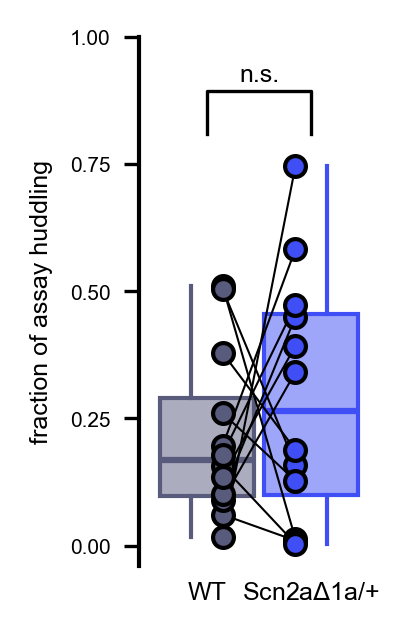

In [151]:
# ----- PLOT MALES, HUDDLE TIME -----

# configure data...
     
metric = 'prop'
wt_col = 'Huddle_WT_'+metric
het_col = 'Huddle_HT_'+metric
na_column = "Unknown_sec"

printstats = True
sex = 'male'
stat = 'huddle time'
statr = stat.replace(' ','-')
lbls = ['WT','Scn2a$ \Delta $1a/+']
fname = f'naiveChoice_huddle-data_choose-{sex}_{statr}_v2.svg'
xlab = ''
ylab = 'fraction of assay huddling'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# Exclude rows that don't meet NA criteria and are sex-specific
df = pd.DataFrame({'WT': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][wt_col], 
                            'Het': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][het_col]})

# make label and title
# ylab = 'fraction of assay'
# ttl = f'NC: choose {sex}\n{stat}'

# make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab)


# stats
thisp = scipy.stats.wilcoxon(df.WT,y=df.Het)
gtp_text = decide_pval_text(thisp[1],0.05)

# make figure
figsz = (1.25,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

# plot
add_pair_to_plot_box(df,'',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,gtp_text)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist],labels=lbls,size=6)
ax.set_yticks([0,0.25,0.5,0.75,1.0])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
# ax.set_title(ttl)
# fig.text(0.375, -0.025, 'WT', ha='center',size=6)
# fig.text(0.825, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

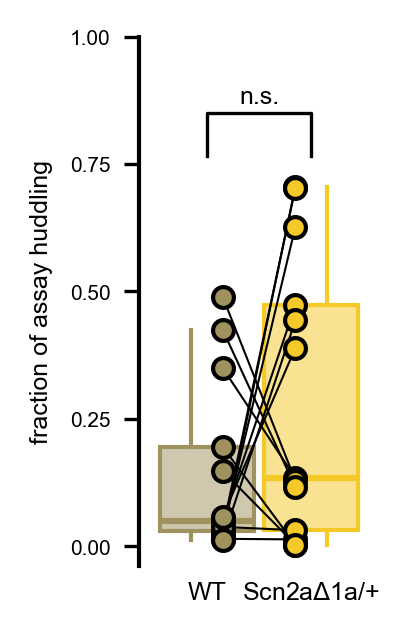

In [152]:
# ----- PLOT FEMALES, HUDDLE TIME -----

# configure data...
     
metric = 'prop'
wt_col = 'Huddle_WT_'+metric
het_col = 'Huddle_HT_'+metric
na_column = "Unknown_sec"

printstats = True
sex = 'female'
stat = 'huddle time'
statr = stat.replace(' ','-')
lbls = ['WT','Scn2a$ \Delta $1a/+']
fname = f'naiveChoice_huddle-data_choose-{sex}_{statr}_v2.svg'
xlab = ''
ylab = 'fraction of assay huddling'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# Exclude rows that don't meet NA criteria and are sex-specific
df = pd.DataFrame({'WT': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][wt_col], 
                            'Het': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][het_col]})

# make label and title
# ylab = 'fraction of assay'
# ttl = f'NC: choose {sex}\n{stat}'

# make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab)


# stats
thisp = scipy.stats.wilcoxon(df.WT,y=df.Het)
gtp_text = decide_pval_text(thisp[1],0.05)

# make figure
figsz = (1.25,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

# plot
add_pair_to_plot_box(df,'',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,gtp_text)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist],labels=lbls,size=6)
ax.set_yticks([0,0.25,0.5,0.75,1.0])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
# ax.set_title(ttl)
# fig.text(0.375, -0.025, 'WT', ha='center',size=6)
# fig.text(0.825, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [144]:
def make_divergent_PPI_plot_with_histogram(df,figsz,cols,ylab):
    
    # set up axes to show vertical histogram
    fig = plt.figure(layout='constrained',figsize=figsz)
    ax = fig.add_subplot()
    ax_histy = ax.inset_axes([0.85, 0, 0.5, 1], sharey=ax)

    # add x axis jitter
    df['jitter'] = np.random.normal(loc=0, scale=dotdist*0.5, size=df.shape[0])
    
    # sort data for coloring
    wtprefIdx = df['prefIdx']>0
    htprefIdx = df['prefIdx']<0
    
    # plot 0 line
    ax.plot([-2.5*dotdist,2.5*dotdist-dotdist],[0,0],':',color=[0.5,0.5,0.5],zorder=-1)
    
    # plot WT dots in WT color
    ax.plot(df[wtprefIdx]['jitter'], df[wtprefIdx]['prefIdx'], 'o', markerfacecolor=cols[0], 
        markeredgecolor='k',zorder=1, ms=5, mew=1)
    
    # plot het dots in het color
    ax.plot(df[htprefIdx]['jitter'], df[htprefIdx]['prefIdx'], 'o', markerfacecolor=cols[1], 
        markeredgecolor='k',zorder=1, ms=5, mew=1)
    
    # calculate stats
    stat, p = scipy.stats.wilcoxon(df['prefIdx'], zero_method = 'pratt')
    if printstats:
        print(f'wilcoxon signed-rank test\tstat: {stat}\tp: {p}')
    
    # plot stats
    ptext = decide_pval_text(p,palpha)
    bottom,top = plt.ylim()
    y, h = top + ppad*top, ppad
    plt.text(0, y+h+0.1*h, ptext, ha='center', va='bottom', color='k',size=6)
    
    # set axis parameters
    ax.set_xlim(-2*dotdist,2.5*dotdist)
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([-1,-0.5,0,0.5,1])
    ax.set_ylabel(ylab)
    
    # marginal density estimate
    density = gaussian_kde(df['prefIdx'])
    xs = np.linspace(-1,1,21)
    density.covariance_factor = lambda : .25
    density._compute_covariance()
    xdat = density(xs)
    
    wtprefIdx = xs>=0
    htprefIdx = xs<=0
    
    ax_histy.plot(xdat[wtprefIdx],xs[wtprefIdx],color=cols[0],linewidth=1.5)
    ax_histy.plot(xdat[htprefIdx],xs[htprefIdx],color=cols[1],linewidth=1.5)
    
    ax_histy.fill_betweenx(xs[wtprefIdx],np.zeros(len(xdat[wtprefIdx])),xdat[wtprefIdx],color=cols[0],alpha=0.5,edgecolor=None)
    ax_histy.fill_betweenx(xs[htprefIdx],np.zeros(len(xdat[htprefIdx])),xdat[htprefIdx],color=cols[1],alpha=0.5,edgecolor=None)
    
    # set axis parameters
    ax_histy.spines['bottom'].set_visible(False)
    ax_histy.set_xticks([])
    plt.setp(ax_histy.get_yticklabels(), visible=False)
    ax.set_ylim([-1.05,1.15])

def make_PPI_piechart(df,cols,figsz):
    # set up data for "wedge"
    wdat = []
    wdat.append(np.sum(df['prefIdx']>0))
    wdat.append(np.sum(df['prefIdx']<0))
    
    # set up plotting properties
    textprops = dict(size=5,ha='center')
    
    # plot
    fig = plt.figure(layout='constrained',figsize=figsz)
    ax = fig.add_subplot()
    lbls = []
    for val in wdat:
        lbls.append(f'n={val}')
    ax.pie(wdat,colors=cols,labels=lbls,labeldistance=0.5,startangle=90,textprops=textprops)
    
    # statistics
    binomr = scipy.stats.binomtest(wdat[1],wdat[0]+wdat[1],p=0.5)
    if printstats:
        print(binomr)
    pval = binomr.pvalue
    ptext = decide_pval_text(p,palpha)
    plt.text(0, 1.05, ptext, ha='center', va='bottom', color='k',size=6)

wilcoxon signed-rank test	stat: 40.0	p: 0.7353515625


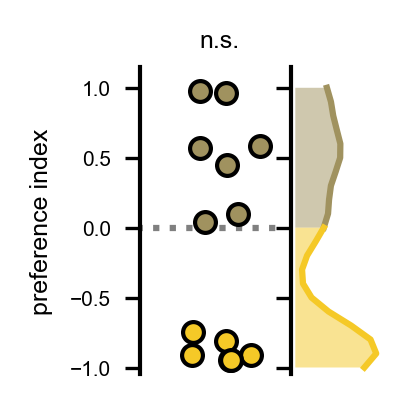

In [154]:
# ----- PLOT FEMALE PPI WITH MARGINAL HISTOGRAM -----

# set up parameters
sex = 'female'
printstats = True
dotdist = 0.1
ylab = 'preference index'
figsz = (1.25,1.25) # total size of figure

fname = f'naive_choice_PPI_dots_distribution_{sex}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# set up data
df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

make_divergent_PPI_plot_with_histogram(df,figsz,cols,ylab)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

wilcoxon signed-rank test	stat: 39.0	p: 1.0


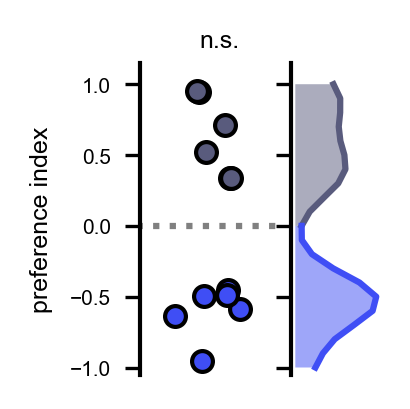

In [157]:
# ----- PLOT MALE PPI WITH MARGINAL HISTOGRAM -----

# set up parameters
sex = 'male'
printstats = True
dotdist = 0.1
ylab = 'preference index'
figsz = (1.25,1.25) # total size of figure

fname = f'naive_choice_PPI_dots_distribution_{sex}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# set up data
df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

make_divergent_PPI_plot_with_histogram(df,figsz,cols,ylab)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

BinomTestResult(k=6, n=13, alternative='two-sided', proportion_estimate=0.46153846153846156, pvalue=1.0)


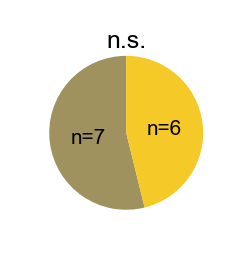

In [160]:
# ----- MAKE PIE CHART FOR FEMALES -----

# set up parameters
sex = 'female'
printstats = True
dotdist = 0.1
ylab = 'preference index'
figsz = (0.75,0.75) # total size of figure

fname = f'naive_choice_PPI_piechart_{sex}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# filter data
df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

make_PPI_piechart(df,cols,figsz)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

BinomTestResult(k=6, n=12, alternative='two-sided', proportion_estimate=0.5, pvalue=1.0)


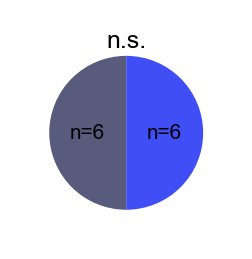

In [161]:
# ----- MAKE PIE CHART FOR MALES -----

# set up parameters
sex = 'male'
printstats = True
dotdist = 0.1
ylab = 'preference index'
figsz = (0.75,0.75) # total size of figure

fname = f'naive_choice_PPI_piechart_{sex}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# filter data
df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

make_PPI_piechart(df,cols,figsz)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [50]:
density

wilcoxon signed-rank test	stat: 40.0	p: 0.7353515625


(-1.05, 1.15)

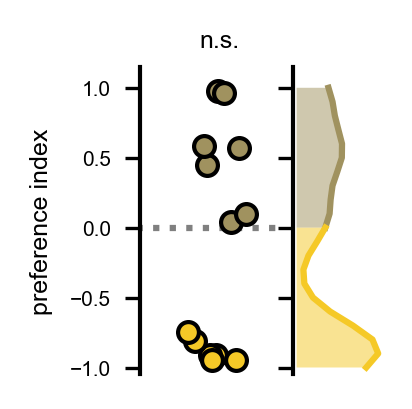

In [111]:
# ----- PLOT PPI WITH MARGINAL HISTOGRAM -----

# set up parameters
sex = 'female'
printstats = True
dotdist = 0.1
ylab = 'preference index'
figsz = (1.25,1.25) # total size of figure


# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# set up axes to show vertical histogram
fig = plt.figure(layout='constrained',figsize=figsz)
ax = fig.add_subplot()
ax_histy = ax.inset_axes([0.85, 0, 0.5, 1], sharey=ax)

# set up data
df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

# add x axis jitter
df['jitter'] = np.random.normal(loc=0, scale=dotdist*0.5, size=df.shape[0])

# sort data for coloring
wtprefIdx = df['prefIdx']>0
htprefIdx = df['prefIdx']<0

# plot 0 line
ax.plot([-2.5*dotdist,2.5*dotdist-dotdist],[0,0],':',color=[0.5,0.5,0.5],zorder=-1)

# plot WT dots in WT color
ax.plot(df[wtprefIdx]['jitter'], df[wtprefIdx]['prefIdx'], 'o', markerfacecolor=cols[0], 
    markeredgecolor='k',zorder=1, ms=5, mew=1)

# plot het dots in het color
ax.plot(df[htprefIdx]['jitter'], df[htprefIdx]['prefIdx'], 'o', markerfacecolor=cols[1], 
    markeredgecolor='k',zorder=1, ms=5, mew=1)

# calculate stats
stat, p = scipy.stats.wilcoxon(df['prefIdx'], zero_method = 'pratt')
if printstats:
    print(f'wilcoxon signed-rank test\tstat: {stat}\tp: {p}')

# plot stats
ptext = decide_pval_text(p,palpha)
bottom,top = plt.ylim()
y, h = top + ppad*top, ppad
plt.text(0, y+h+0.1*h, ptext, ha='center', va='bottom', color='k',size=6)

# set axis parameters
ax.set_xlim(-2*dotdist,2.5*dotdist)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([-1,-0.5,0,0.5,1])
ax.set_ylabel(ylab)

# marginal density estimate
density = gaussian_kde(df['prefIdx'])
xs = np.linspace(-1,1,21)
density.covariance_factor = lambda : .25
density._compute_covariance()
xdat = density(xs)

wtprefIdx = xs>=0
htprefIdx = xs<=0

ax_histy.plot(xdat[wtprefIdx],xs[wtprefIdx],color=cols[0],linewidth=1.5)
ax_histy.plot(xdat[htprefIdx],xs[htprefIdx],color=cols[1],linewidth=1.5)

ax_histy.fill_betweenx(xs[wtprefIdx],np.zeros(len(xdat[wtprefIdx])),xdat[wtprefIdx],color=cols[0],alpha=0.5,edgecolor=None)
ax_histy.fill_betweenx(xs[htprefIdx],np.zeros(len(xdat[htprefIdx])),xdat[htprefIdx],color=cols[1],alpha=0.5,edgecolor=None)

# set axis parameters
ax_histy.spines['bottom'].set_visible(False)
ax_histy.set_xticks([])
plt.setp(ax_histy.get_yticklabels(), visible=False)
ax.set_ylim([-1.05,1.15])

BinomTestResult(k=6, n=13, alternative='two-sided', proportion_estimate=0.46153846153846156, pvalue=1.0)


Text(0, 1.05, 'n.s.')

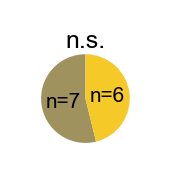

In [143]:
# ----- MAKE PIE CHART WITH FISHER TEST -----

# set up parameters
sex = 'female'
printstats = True
dotdist = 0.1
ylab = 'preference index'
figsz = (0.5,0.5) # total size of figure

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# filter data
df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

# set up data for "wedge"
wdat = []
wdat.append(np.sum(df['prefIdx']>0))
wdat.append(np.sum(df['prefIdx']<0))

# set up plotting properties
textprops = dict(size=5,ha='center')

# plot
fig = plt.figure(layout='constrained',figsize=figsz)
ax = fig.add_subplot()
lbls = []
for val in wdat:
    lbls.append(f'n={val}')
ax.pie(wdat,colors=cols,labels=lbls,labeldistance=0.5,startangle=90,textprops=textprops)

# statistics
binomr = scipy.stats.binomtest(wdat[1],wdat[0]+wdat[1],p=0.5)
if printstats:
    print(binomr)
pval = binomr.pvalue
ptext = decide_pval_text(p,palpha)
plt.text(0, 1.05, ptext, ha='center', va='bottom', color='k',size=6)